# TO DO

- doublecheck remaining functions in the workshopfile to be added (from section "ExcludeVector" downwards)
- asArea=True doenst work (cf. 01_placement file)
- Finalize short introduction  
- check which data might be still missing (gis_osm data..?)

? MIssing Data files:
    ? Smopy: gis_osm_roads_free_1.shp
    ? wdpa_V.tif in gk.drawRaster("./intermediate_files/wdpa_V.tif")
    ? WDPA_Jul2020-shapefile-polygons.shp (4 GB alternative) [JM] got them from Julia
    ? "C:\Users\s.ryberg\FZJ\data\geography\global_wind_atlas\gwa3_250_wind-speed_100m.NRW.tif" #shared data
    ? axialDirection="C:/Users/s.ryberg/FZJ/repos/res/reskit/weather/Era5Source/data/ERA5_wind_direction_100m_mean.tiff" # gk, clipping


? srs = LAEA vs 3035 ? [@chris]d


In the following everything from 00_basic_workflow.ipynb, thats not yet used in 00_basic_workflow_new.ipynb or 01_Placement_algorithm_new.ipynb, is listed

# Introduction

This workbook presents multiple more functions of GLAES:

### Overview:
1) Using exclusion sets
2) Reinitializing previous ExclusionCalculators
3) Drawing with basemaps
4) Accessing grid information
5) Considering region boundary effects with padExtent 
6) excludeRasterType with ranges for clc classes
7) IncludeRasterType
8) Working with Digital Elevation Maps DEM Mosaics to exclude Raster

In [24]:
# Import GLAES
import glaes as gl
import geokit as gk
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# Choose a region to operate on (Here, a predefined region for Aachen, Germany is used)
regionPath = gl._test_data_["aachenShapefile.shp"]

clc_path = gl._test_data_["clc-aachen_clipped.tif"]

# Function to initialize new ExclusionCalculator object
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# 1. Working with Exclusion Sets

In [26]:
import pandas as pd

# exclusion_set = pd.read_csv("sample_exclusion_set.csv")
exclusion_set = pd.read_csv(gl._test_data_["sample_exclusion_set.csv"])
exclusion_set

,name,type,value,buffer
0,clc,raster,[12-22],NaN
1,clc,raster,[1-2],1000.0
2,osm_roads,vector,type='motorway' OR type='primary' OR type='trunk',200.0


Excluding Raster clc with value [12-22], buffer None, mode exclude, and invert False
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 83.86328125 MB


Excluding Raster clc with value [1-2], buffer 1000.0, mode exclude, and invert False


Memory useage during calc: 86.1875 MB


Excluding Vector osm_roads with where-statement "type='motorway' OR type='primary' OR type='trunk'", buffer 200.0, mode exclude, and invert False 
c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:1560: UserWarning: Memory efficient multiProcess failed, returning to safe linear processing.
  warn(


Memory useage during calc: 204.25390625 MB


Done!


<Axes: >

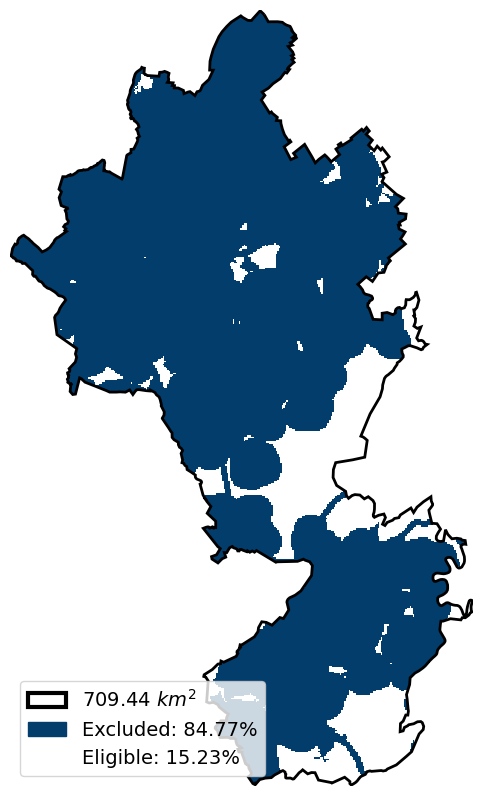

In [27]:
## Make a new ExclusoinCalculator
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

## Apply exclusions from the given set
ec.excludeSet(
    exclusion_set=exclusion_set,
    clc=gl._test_data_["clc-aachen_clipped.tif"],
    osm_roads=gl._test_data_["aachenRoads.shp"],
)

## Draw result
ec.draw()

# 2. Reinitialize an ExclusionCalculator from a pre-computed result

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 224.21484375 MB


<Axes: >

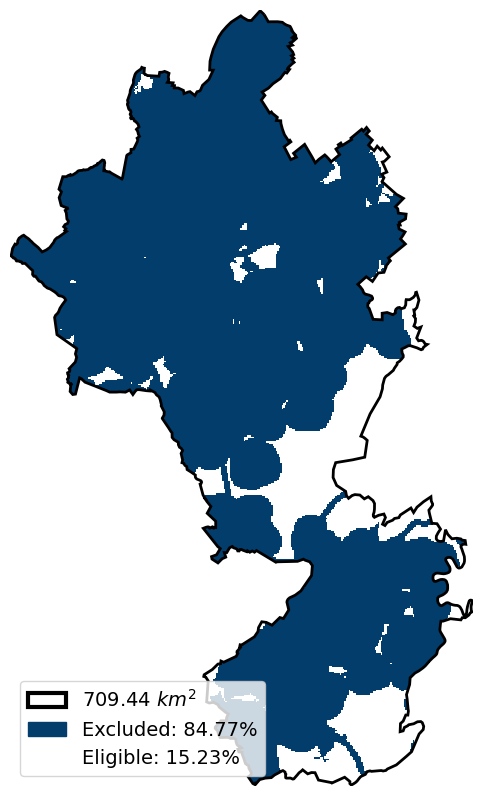

In [ ]:
## Set the initial value to those we computed previously. This is particularly useful if the original calculation took a while
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100, initialValue="tmp/aachens_best_pv_spots.tif")

## Draw the result
ec.draw()

# 3. Draw exclusions with a basemap

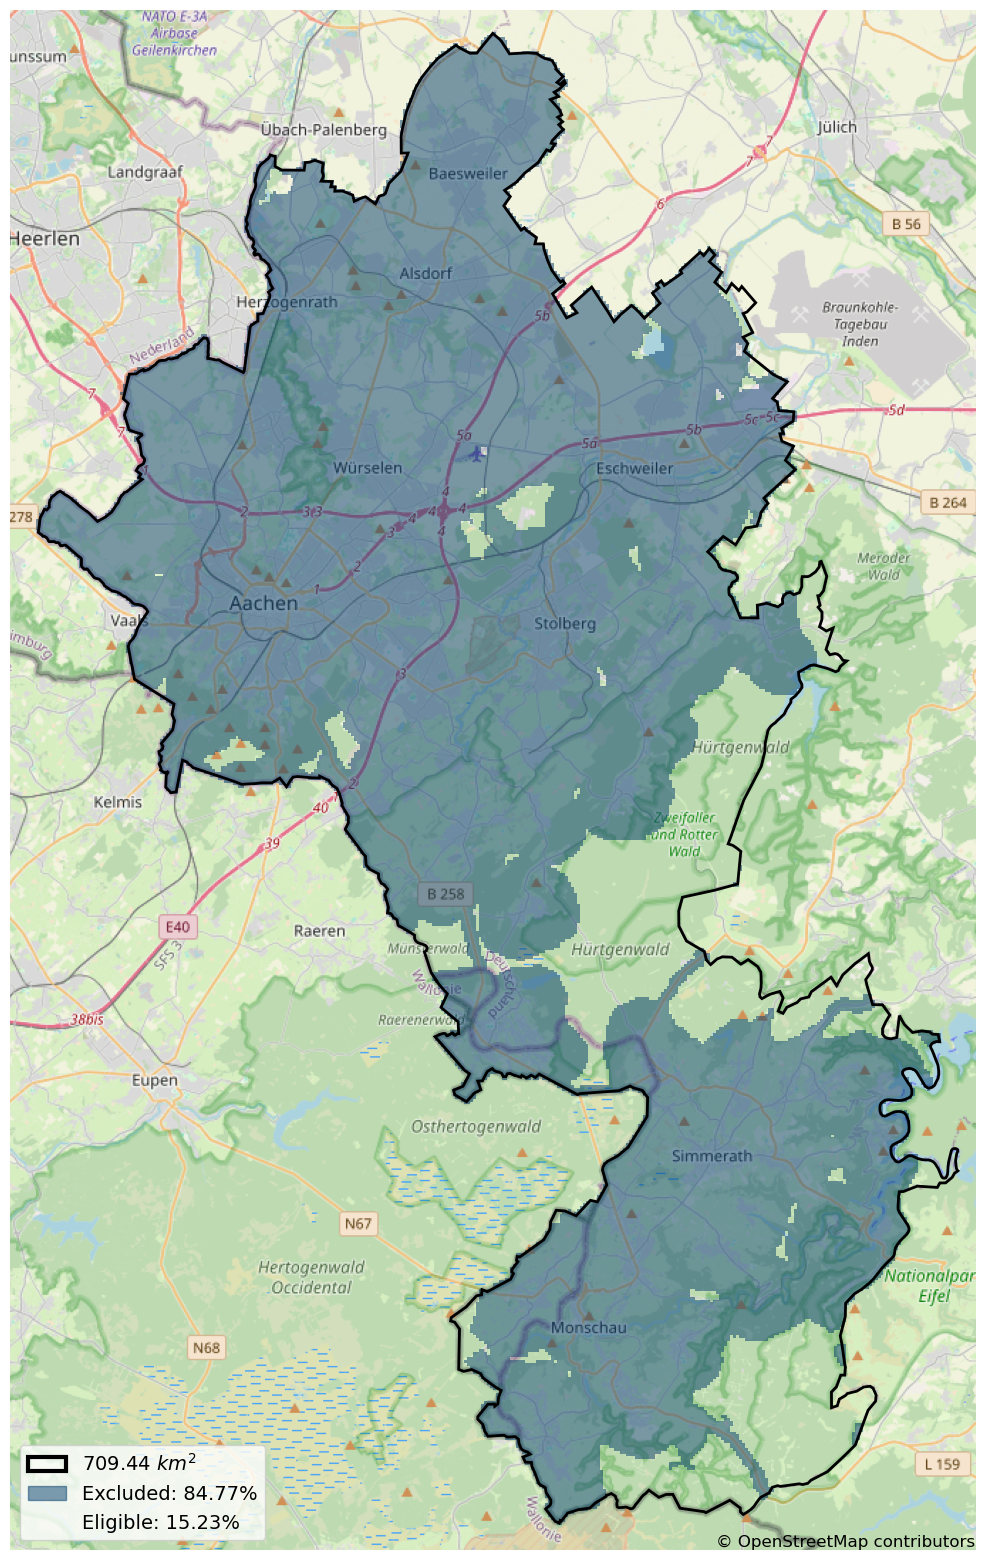

In [ ]:
# Be careful to not use a too-high zoom level!
# Also don't forget about using the right attribution

ax = ec.drawWithSmopyBasemap(zoom=11, figsize=(40, 20))

# 4. Access grid information of the ExclusionCalculator

In [14]:
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# Bounding box: smallest rectangle around the region (units: meter, refering to srs)
ec.region.extent
# Mask: Pixel grid inside bounding box, according to pixelRes (True = inside regiion, False = outside region)
ec.region.mask
# Get shape of the mask (rows, columns)
ec.region.mask.shape

(509, 304)

# 5. Considering region boundary effects with padExtent 

In [ ]:
# padExtent adds a padding buffer around your region’s bounding box so calculations near the border don’t miss features just outside the region.
# Without padding, buffers (e.g., a 3 km exclusion zone) that extend beyond the region get cut off at the boundary, so edge effects are computed incorrectly.
# With padExtent, you include enough surrounding raster to fully apply those buffers—e.g., a road 1 km outside the boundary can still correctly exclude the
# 2 km of area inside the region that falls within a 3 km buffer. Because of this padding, the region extent coordinates change, and the mask/grid shape 
# (size) increases.

ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs=3035, 
    pixelRes=100,
    padExtent=0
    )

print(ec.region.extent)
print(ec.region.mask.shape)

ec = gl.ExclusionCalculator(
    region=regionPath, 
    srs=3035, 
    pixelRes=100,
    padExtent=2000
    )

print(ec.region.extent)
print(ec.region.mask.shape)

(4037300.00000,3049300.00000,4067700.00000,3100200.00000)
(509, 304)
(4035300.00000,3047300.00000,4069700.00000,3102200.00000)
(549, 344)


# 6. excludeRasterType with ranges for clc classes

Memory useage during calc: 241.2890625 MB


<Axes: >

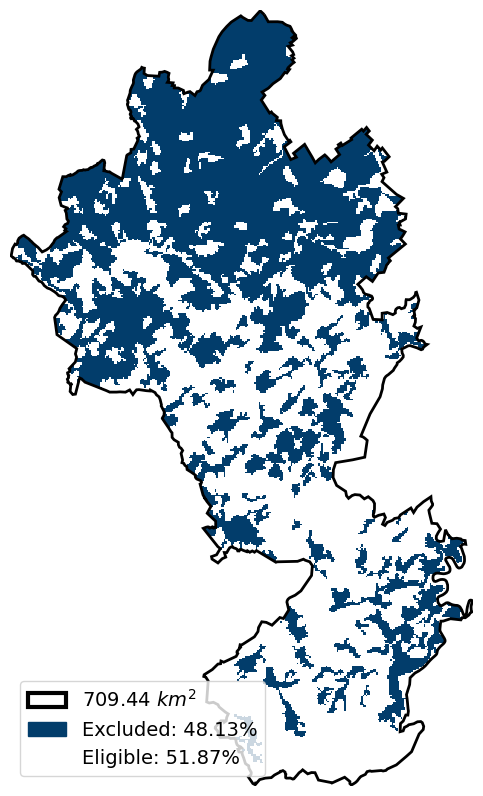

In [16]:
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]") # syntax for using ranges
ec.draw()

# 7. Alternative filter  (include, invert, initialValue)

Memory useage during calc: 245.96875 MB


<Axes: >

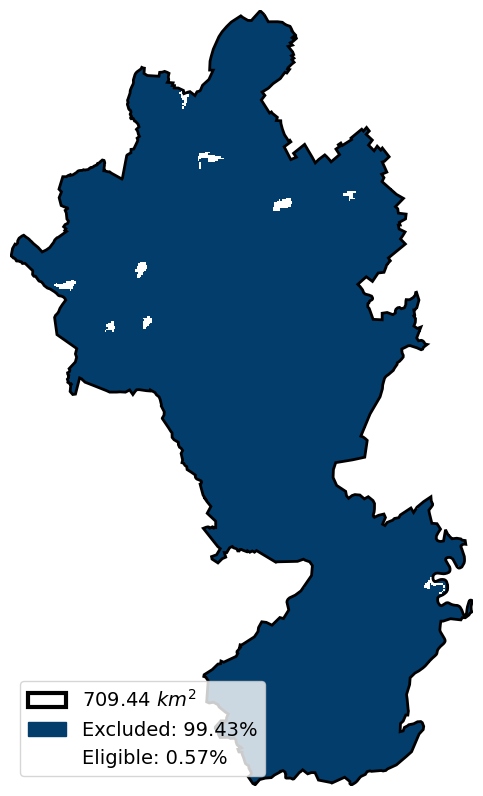

In [17]:
# use include mode to start with full exclusion and only include the specified clc classes to be eligible

ec = gl.ExclusionCalculator(
        region=regionPath,
        srs=3035, 
        pixelRes=100,
        initialValue=False
        )

ec.excludeRasterType(source=clc_path, value=11, mode="include")

ec.draw()

Memory useage during calc: 248.1015625 MB


0.565234551195309

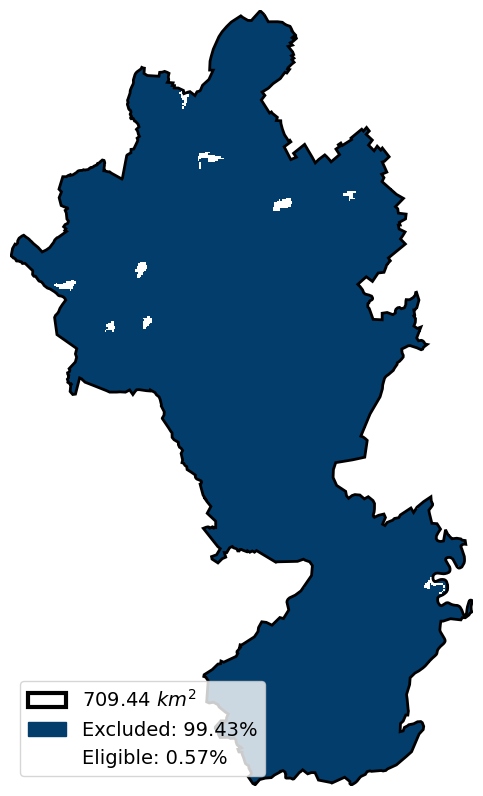

In [18]:
# invert excludeRasterType
ec = gl.ExclusionCalculator(
        region=regionPath,
        srs=3035, 
        pixelRes=100,
        initialValue=False
        )

ec.excludeRasterType(source=clc_path, value=11, mode="include", invert=False)

ec.draw()
ec.percentAvailable

Memory useage during calc: 252.58203125 MB


<Axes: >

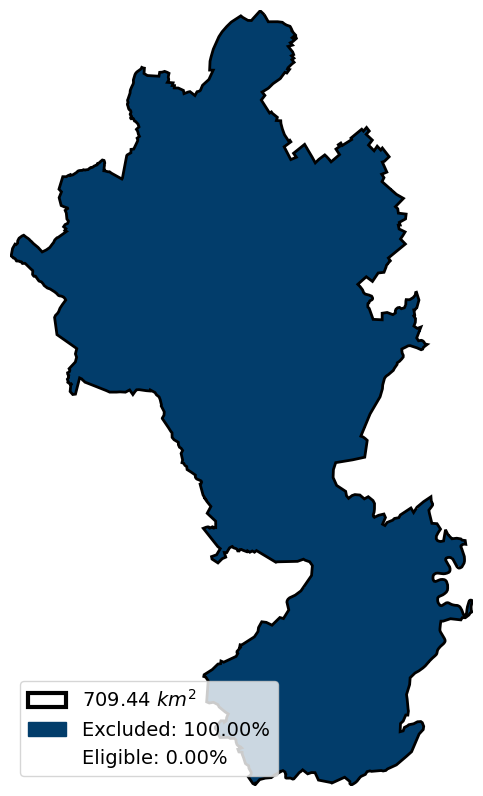

In [19]:
ec.excludeRasterType(source=clc_path, value="[1-2],12,[21-23]", invert=True)

ec.draw()

# 8. Working with DEM Mosaics to exclude Raster

<class 'osgeo.gdal.Dataset'>


AxHands(ax=<Axes: >, handles=<matplotlib.image.AxesImage object at 0x0000014947BE3B50>, cbar=<matplotlib.colorbar.Colorbar object at 0x0000014947BF6680>)

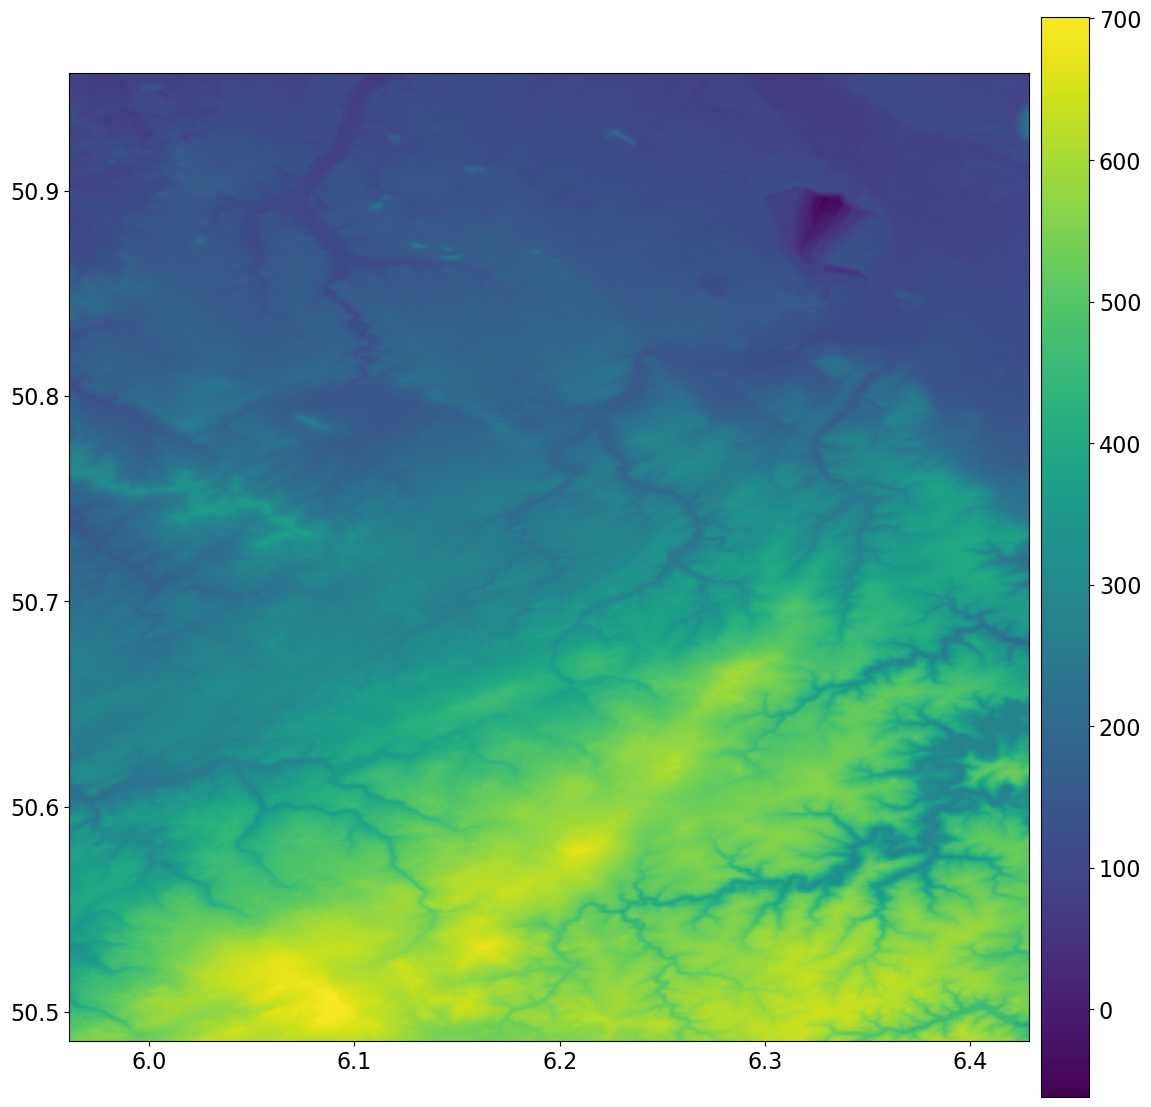

In [ ]:
# Create an elevation mosaic heatmap from digital elevation model (DEM) files. DEMs are raster 
# grids where each pixel stores the ground elevation, forming a digital model of the terrain’s 
# height. Data can be found and downloaded for other regions from https://dwtkns.com/srtm30m . 
# Note, that multiple files might be necessary if your region is large or spans multiple tiles. 
# All files put into .rasterMosaic() will be merged to a single raster mosaic covering the entire region. 

import geokit as gk

dem_raster = ec.region.extent.rasterMosaic(r"C:\Users\j.mutke\Desktop\GLAES_Github\glaes\glaes\test\data\*.hgt")
print(type(dem_raster)) # multiple DEM files merged into a single raster mosaic
gk.drawRaster(dem_raster)


c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 139.7109375 MB


<Axes: >

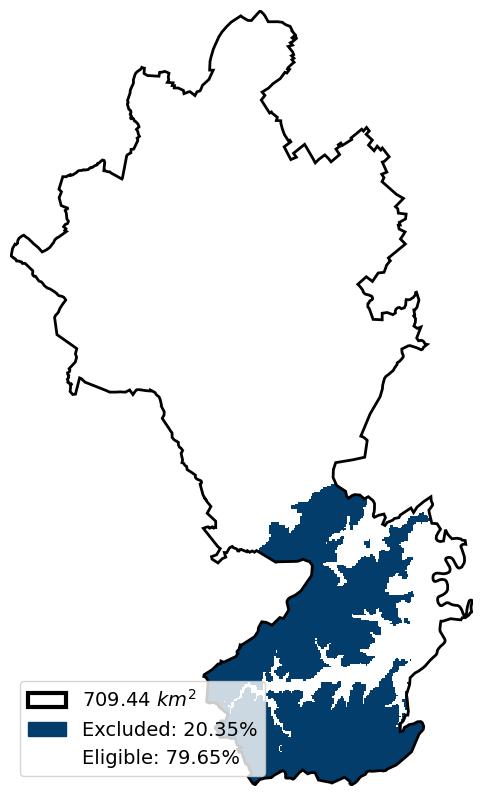

In [ ]:
# exclude areas above 500m elevation. Note, that here the hilly Eiffel region is mainly exluded in the region's south.
ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_raster, value="(500-]", resampleAlg="mode")
ec.draw()

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 202.3984375 MB


<Axes: >

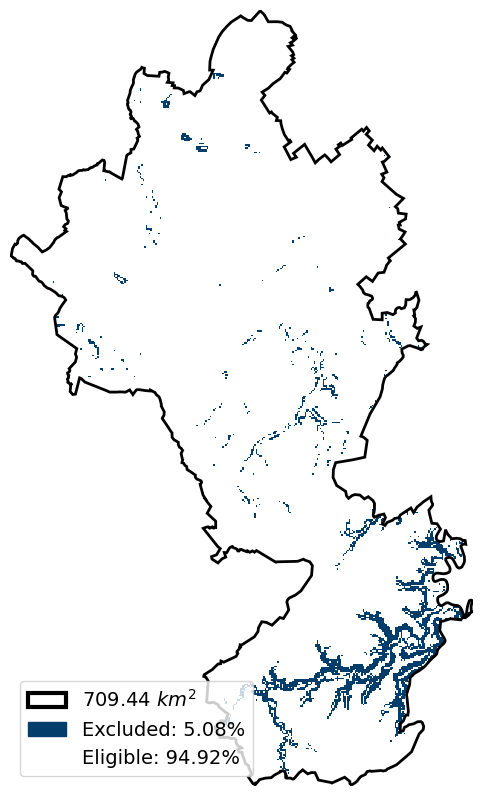

In [ ]:
# Exclude Raster - DEM Gradient Mosaic. Exlude slopes above 15 degrees.

dem_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(                          # computes the gradient (slope) of a raster
            source=dem_raster,
            factor="latlonToM"),                        # factor to convert lat/lon degrees to meters
    processor=lambda x: np.degrees(np.arctan(x))        # convert gradient to degrees
)

ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)
ec.excludeRasterType(dem_gradiate_raster, value=(15, None), resampleAlg="mode")

ec.draw()

c:\Users\j.mutke\AppData\Local\miniforge3\envs\glaes\lib\site-packages\geokit\core\regionmask.py:958: UserWarning: Multiprocessing has been set to 'False' because it is not available for Windows or Mac. To deactivate this warning, please set the multiProcess variable to False. On Windows and Mac, new processes must be spawned, which requires the serialisation of the method to be executed via multiprocessing. However, Geokit contains objects that cannot be serialised by Pickle. On Linux, however, new processes are inherited and no serialisation is required.
  warn(multi_processing_warning_message)


Memory useage during calc: 253.125 MB
<osgeo.gdal.Dataset; proxy of <Swig Object of type 'GDALDatasetShadow *' at 0x000001494E613990> >


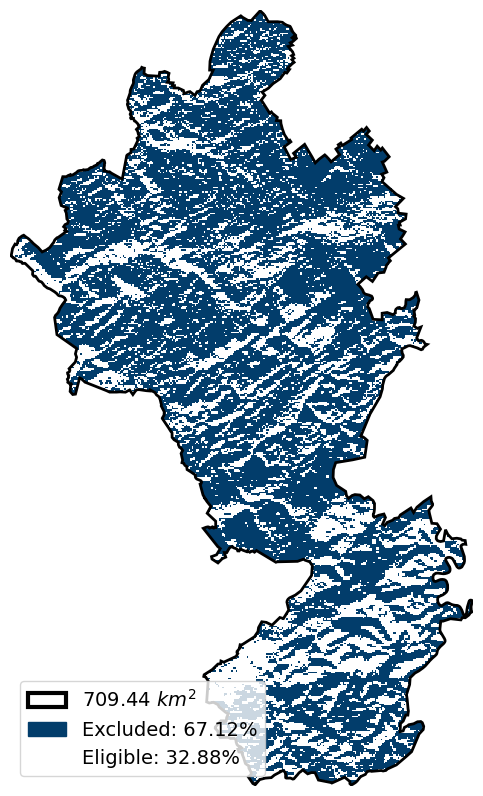

In [ ]:
# Exlude slopes with north orientation, as north facing slopes receive less radiation.

dem_ns_gradiate_raster = gk.raster.mutateRaster(
    source=gk.raster.gradient(
            source=dem_raster,
            factor="latlonToM",
            mode="north-south"),
    processor=lambda matrix: np.degrees(np.arctan(matrix))
)

ec = gl.ExclusionCalculator(regionPath, srs=3035, pixelRes=100)

# exclude all north facing slopes (values > 0 degrees)
ec.excludeRasterType(dem_ns_gradiate_raster, value=(0, None), resampleAlg="mode")

ec.draw()

# 9. ExcludeVectorType (In Progress)

In [20]:
def make_new_ec(**kwargs):
    
    ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        **kwargs)
    return ec

In [ ]:
#  Exclude Vector - Simple source w/ where clause

ec = make_new_ec()
ec.excludeVectorType(
    source=r"C:\Users\s.ryberg\FZJ\data\geography\protected_areas\protected_planet\WDPA_Jul2020-shapefile2\WDPA_Jul2020-shapefile-polygons.shp",
    where="IUCN_CAT='V'",
)

ec.draw()

GeoKitVectorError: ('Could not load input dataSource: ', 'C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/WDPA_Feb2020-shapefile-points.shp')

In [ ]:
# Exclude Vector - resolutionDiv
def make_new_ec(**kwargs):
    
    ec = gl.ExclusionCalculator(
        region=gk._test_data_['aachenShapefile.shp'],
        srs="LAEA", 
        pixelRes=50,
        padExtent=5000,
        **kwargs)
    return ec

ec = make_new_ec()
ec.draw()

ec.excludeVectorType(
    source=r"C:\Users\s.ryberg\FZJ\data\geography\OSM\NRW\gis_osm_buildings_a_free_1.shp",
    resolutionDiv=8,
    forceMaskShape=True
)

ec.draw()

# 10 Visualization Methods (Smopy)

AxHands(ax=<Axes: >, handles=0       [Line2D(_child1715)]
1       [Line2D(_child1716)]
2       [Line2D(_child1717)]
3       [Line2D(_child1718)]
4       [Line2D(_child1719)]
                ...         
1708    [Line2D(_child3423)]
1709    [Line2D(_child3424)]
1710    [Line2D(_child3425)]
1711    [Line2D(_child3426)]
1712    [Line2D(_child3427)]
Length: 1713, dtype: object, cbar=None)

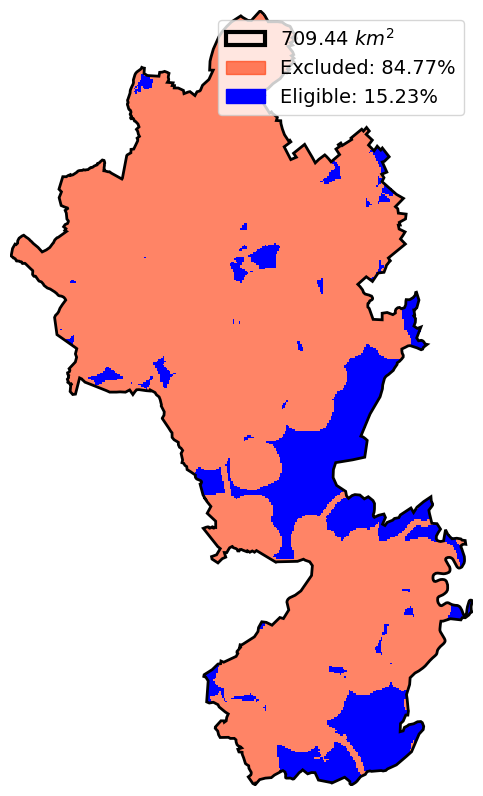

In [29]:
ec.draw(
    goodColor="blue",
    excludedColor=(1.0, 0.2, 0.0, 0.6),
    legendargs={'loc': 'upper right'},)

# ax = ec.draw()
roads = gk.vector.extractFeatures(r"C:/Users/j.mutke/Desktop/GLAES_Github/glaes/glaes/test/data/aachenRoads.shp", 
                                  where="type='motorway' OR type='primary' OR type='trunk'",
                                  geom=ec.region.geometry)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=ec.region.srs)


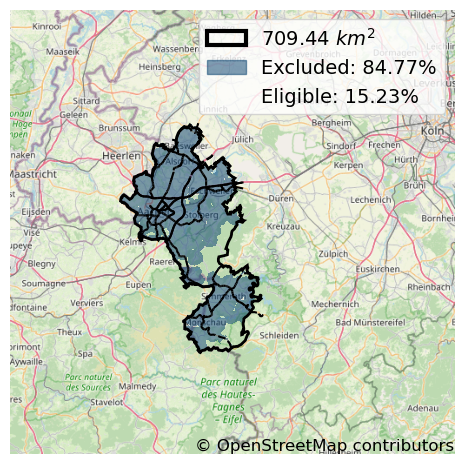

In [30]:
# Draw with Smopy
## Importance of attribution statement!!

ax = ec.drawWithSmopyBasemap(
    zoom=9,
    legendargs={'loc': 'upper right'},)
gk.drawGeoms(roads, ax=ax, color='k', linestyle="--", srs=gk.srs.EPSG3857)

plt.show()

# Miscellaneous

In [ ]:
# Exclude Raster - resolutionDiv
# Exclude Raster - prewarp
# Exclude Raster - resampleAlg -> "Down sampling": near,bilinear,cubic  "upsampling":average,mode,max,min

gk.drawRaster("./intermediate_files/wdpa_V.tif")


# advanced placement methods from workshop
ec.save?
ec.save("exclusion_result.tif", threshold=90)

0.565234551195309